In [3]:
import sys
print(sys.executable)
!{sys.executable} -m pip install lightgbm

c:\Users\atefe\.pyenv\pyenv-win\versions\3.11.3\python.exe


In [4]:
from lightgbm import LGBMRegressor

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
import sys
!{sys.executable} -m pip install lightgbm xgboost catboost seaborn

In [ ]:
# =========================================================
# 1. Imports
# =========================================================

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Display settings
sns.set_style("darkgrid", rc={"axes.facecolor": "white", "grid.color": ".8"})
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [ ]:
# =========================================================
# 2. Load data
# =========================================================

# Load the final feature dataset and parse the timestamp column as datetime
df = pd.read_csv("../data/df_features.csv", parse_dates=["timestamp"])

# Sort the data chronologically and reset the index
df = df.sort_values("timestamp").reset_index(drop=True)

# Show basic checks
print("Shape:", df.shape)
print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())
display(df.head(2))


Shape: (62544, 38)
Date range: 2019-01-15 00:00:00 to 2026-03-04 23:00:00


,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,price_lag_24h,price_lag_168h,price_rolling_24h,price_rolling_168h,is_holiday,is_hol_or_week,price_volatility_24h,gas_price_lag_24h,gas_price_lag_168h,coal_price_lag_24h,coal_price_lag_168h,co2_price_lag_24h,total_generation_lag_24h,total_generation_lag_168h,net_export_lag_24h,net_export_lag_168h,is_peak_hour,wind_x_peak,solar_x_demand,is_crisis_period,year,residual_load,load_ramp,renewable_ramp,total_wind_forecast,delta_wind_forecast
0,2019-01-15 00:00:00,35.18,54057.25,4999.00,24868.25,0.0,0,1,1,1.2875,32.516594,False,-3.14,17.94,32.610833,40.085952,False,False,24.249786,21.674999,22.09,82.0,82.150002,21.95,66572.75,68405.50,13188.0,13001.0,0,0.0,0.0,0,2019,24190.00,-1161.0,-1270.50,29867.25,-12156.0
1,2019-01-15 01:00:00,35.82,52364.25,4923.25,25149.75,0.0,1,1,1,1.2000,32.459120,False,-12.00,20.91,34.207500,40.188571,False,False,23.024083,21.674999,22.09,82.0,82.150002,21.95,65146.75,68068.25,13065.0,13461.0,0,0.0,0.0,0,2019,22291.25,-1693.0,205.75,30073.00,-11445.5


In [ ]:
# =========================================================
# 3. Define the final feature set
# =========================================================

# Use all columns except timestamp and target as model features
feature_cols = [col for col in df.columns if col not in ["timestamp", "price"]]

# Show basic feature information
print("Number of selected features:", len(feature_cols))
print(feature_cols)

# Preview the selected feature columns
display(df[feature_cols].head(2))

Number of selected features: 36
['load', 'wind_offshore', 'wind_onshore', 'solar', 'hour', 'day_of_week', 'month', 'temperature', 'wind_speed', 'is_weekend', 'price_lag_24h', 'price_lag_168h', 'price_rolling_24h', 'price_rolling_168h', 'is_holiday', 'is_hol_or_week', 'price_volatility_24h', 'gas_price_lag_24h', 'gas_price_lag_168h', 'coal_price_lag_24h', 'coal_price_lag_168h', 'co2_price_lag_24h', 'total_generation_lag_24h', 'total_generation_lag_168h', 'net_export_lag_24h', 'net_export_lag_168h', 'is_peak_hour', 'wind_x_peak', 'solar_x_demand', 'is_crisis_period', 'year', 'residual_load', 'load_ramp', 'renewable_ramp', 'total_wind_forecast', 'delta_wind_forecast']


,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,price_lag_24h,price_lag_168h,price_rolling_24h,price_rolling_168h,is_holiday,is_hol_or_week,price_volatility_24h,gas_price_lag_24h,gas_price_lag_168h,coal_price_lag_24h,coal_price_lag_168h,co2_price_lag_24h,total_generation_lag_24h,total_generation_lag_168h,net_export_lag_24h,net_export_lag_168h,is_peak_hour,wind_x_peak,solar_x_demand,is_crisis_period,year,residual_load,load_ramp,renewable_ramp,total_wind_forecast,delta_wind_forecast
0,54057.25,4999.00,24868.25,0.0,0,1,1,1.2875,32.516594,False,-3.14,17.94,32.610833,40.085952,False,False,24.249786,21.674999,22.09,82.0,82.150002,21.95,66572.75,68405.50,13188.0,13001.0,0,0.0,0.0,0,2019,24190.00,-1161.0,-1270.50,29867.25,-12156.0
1,52364.25,4923.25,25149.75,0.0,1,1,1,1.2000,32.459120,False,-12.00,20.91,34.207500,40.188571,False,False,23.024083,21.674999,22.09,82.0,82.150002,21.95,65146.75,68068.25,13065.0,13461.0,0,0.0,0.0,0,2019,22291.25,-1693.0,205.75,30073.00,-11445.5


In [ ]:
# =========================================================
# 4. Check the selected feature set
# =========================================================

# Show number of features
print("Number of selected features:", len(feature_cols))

# Show data type counts
display(df[feature_cols].dtypes.value_counts())

# Show missing values in the selected features
display(df[feature_cols].isna().sum().sort_values(ascending=False).head(20))

Number of selected features: 36


float64    27
int64       6
bool        3
Name: count, dtype: int64

load                         0
wind_offshore                0
coal_price_lag_168h          0
co2_price_lag_24h            0
total_generation_lag_24h     0
total_generation_lag_168h    0
net_export_lag_24h           0
net_export_lag_168h          0
is_peak_hour                 0
wind_x_peak                  0
solar_x_demand               0
is_crisis_period             0
year                         0
residual_load                0
load_ramp                    0
renewable_ramp               0
total_wind_forecast          0
coal_price_lag_24h           0
gas_price_lag_168h           0
gas_price_lag_24h            0
dtype: int64

In [ ]:
# =========================================================
# 5. Create the hourly train, validation, and test split
# =========================================================

# Create chronological masks
train_mask = df["timestamp"] < "2025-01-01"
val_mask = (df["timestamp"] >= "2025-01-01") & (df["timestamp"] < "2025-07-01")
test_mask = df["timestamp"] >= "2025-07-01"

# Create split dataframes
train_df = df.loc[train_mask].copy()
val_df = df.loc[val_mask].copy()
test_df = df.loc[test_mask].copy()

# Show split shapes
print("train_df:", train_df.shape)
print("val_df:", val_df.shape)
print("test_df:", test_df.shape)

# Show split date ranges
print("Train range:", train_df["timestamp"].min(), "to", train_df["timestamp"].max())
print("Validation range:", val_df["timestamp"].min(), "to", val_df["timestamp"].max())
print("Test range:", test_df["timestamp"].min(), "to", test_df["timestamp"].max())

train_df: (52272, 38)
val_df: (4344, 38)
test_df: (5928, 38)
Train range: 2019-01-15 00:00:00 to 2024-12-31 23:00:00
Validation range: 2025-01-01 00:00:00 to 2025-06-30 23:00:00
Test range: 2025-07-01 00:00:00 to 2026-03-04 23:00:00


In [ ]:
# =========================================================
# 6. Create sample weights for the training period
# =========================================================

# Create default training weights
train_weights = pd.Series(1.0, index=train_df.index)

# Assign regime-based weights
train_weights.loc[(train_df["timestamp"] >= "2019-01-01") & (train_df["timestamp"] < "2021-01-01")] = 0.6
train_weights.loc[(train_df["timestamp"] >= "2021-01-01") & (train_df["timestamp"] < "2023-01-01")] = 0.3
train_weights.loc[(train_df["timestamp"] >= "2023-01-01") & (train_df["timestamp"] < "2025-01-01")] = 1.0

# Show the weight distribution
display(train_weights.value_counts().sort_index())
display(train_weights.head())

0.3    17520
0.6    17208
1.0    17544
Name: count, dtype: int64

0    0.6
1    0.6
2    0.6
3    0.6
4    0.6
dtype: float64

In [ ]:
# =========================================================
# 7. Create hourly feature matrices and targets
# =========================================================

# Create feature matrices
X_train = train_df[feature_cols].copy()
X_val = val_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

# Create targets
y_train = train_df["price"].copy()
y_val = val_df["price"].copy()
y_test = test_df["price"].copy()

# Show shapes
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (52272, 36)
X_val: (4344, 36)
X_test: (5928, 36)
y_train: (52272,)
y_val: (4344,)
y_test: (5928,)


In [ ]:
# =========================================================
# 8. Build the naive hourly benchmark
# =========================================================

# Define a function for the naive hourly forecast
def predict_price_lag_hourly(df_input, price_col="price", day_col="day_of_week"):
    # Create 24-hour and 168-hour lagged prices
    lag_1 = df_input[price_col].shift(24)
    lag_7 = df_input[price_col].shift(168)

    # Use D-1 for Tue, Wed, Thu, Fri, Sun and D-7 for Mon, Sat
    lag_1_days = {1, 2, 3, 4, 6}

    # Return the naive prediction series
    return pd.Series(
        np.where(df_input[day_col].isin(lag_1_days), lag_1, lag_7),
        index=df_input.index
    )

# Create naive hourly predictions for the full dataframe
df["price_pred_naive"] = predict_price_lag_hourly(df)

# Extract naive predictions for validation and test
y_val_naive = df.loc[val_df.index, "price_pred_naive"].copy()
y_test_naive = df.loc[test_df.index, "price_pred_naive"].copy()

In [ ]:
# =========================================================
# 9. Define evaluation metrics
# =========================================================

# Define hourly MAE
def mae_hourly(y_true, y_pred):
    # Compute the mean absolute error
    return mean_absolute_error(y_true, y_pred)

# Define daily average error based on hourly predictions
def dae_hourly(y_true, y_pred, timestamps):
    # Build a temporary dataframe with timestamps, true values, and predictions
    eval_df = pd.DataFrame({
        "timestamp": timestamps,
        "y_true": y_true,
        "y_pred": y_pred
    })

    # Aggregate to daily sums
    daily_eval = eval_df.groupby(eval_df["timestamp"].dt.floor("D")).agg({
        "y_true": "sum",
        "y_pred": "sum"
    })

    # Compute the mean daily average error
    return np.mean(np.abs(daily_eval["y_true"] - daily_eval["y_pred"]) / 24)

# Define relative MAE against the naive benchmark
def rmae(model_mae, naive_mae):
    # Compute relative MAE
    return model_mae / naive_mae

In [ ]:
# =========================================================
# 10. Evaluate the naive benchmark
# =========================================================

# Compute naive validation metrics
naive_val_mae = mae_hourly(y_val, y_val_naive)
naive_val_dae = dae_hourly(y_val, y_val_naive, val_df["timestamp"])

# Compute naive test metrics
naive_test_mae = mae_hourly(y_test, y_test_naive)
naive_test_dae = dae_hourly(y_test, y_test_naive, test_df["timestamp"])

# Print validation results
print("Naive validation MAE:", round(naive_val_mae, 4))
print("Naive validation DAE:", round(naive_val_dae, 4))

# Print test results
print("Naive test MAE:", round(naive_test_mae, 4))
print("Naive test DAE:", round(naive_test_dae, 4))

Naive validation MAE: 28.4176
Naive validation DAE: 22.5712
Naive test MAE: 23.2938
Naive test DAE: 18.7708


In [ ]:
# =========================================================
# 11. Build the Lasso baseline
# =========================================================

# Build a pipeline with feature scaling and Lasso
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.01, max_iter=10000, random_state=42))
])

# Fit the Lasso model on the training data with sample weights
lasso_model.fit(X_train, y_train, model__sample_weight=train_weights)

# Predict on validation and test data
y_val_pred_lasso = pd.Series(lasso_model.predict(X_val), index=y_val.index)
y_test_pred_lasso = pd.Series(lasso_model.predict(X_test), index=y_test.index)

In [ ]:
# =========================================================
# 12. Evaluate the Lasso baseline
# =========================================================

# Compute Lasso validation metrics
lasso_val_mae = mae_hourly(y_val, y_val_pred_lasso)
lasso_val_dae = dae_hourly(y_val, y_val_pred_lasso, val_df["timestamp"])
lasso_val_rmae = rmae(lasso_val_mae, naive_val_mae)

# Compute Lasso test metrics
lasso_test_mae = mae_hourly(y_test, y_test_pred_lasso)
lasso_test_dae = dae_hourly(y_test, y_test_pred_lasso, test_df["timestamp"])
lasso_test_rmae = rmae(lasso_test_mae, naive_test_mae)

# Print validation results
print("Lasso validation MAE:", round(lasso_val_mae, 4))
print("Lasso validation DAE:", round(lasso_val_dae, 4))
print("Lasso validation RMAE:", round(lasso_val_rmae, 4))

# Print test results
print("Lasso test MAE:", round(lasso_test_mae, 4))
print("Lasso test DAE:", round(lasso_test_dae, 4))
print("Lasso test RMAE:", round(lasso_test_rmae, 4))

Lasso validation MAE: 15.636
Lasso validation DAE: 9.618
Lasso validation RMAE: 0.5502
Lasso test MAE: 14.952
Lasso test DAE: 9.2665
Lasso test RMAE: 0.6419


In [ ]:
# =========================================================
# 13. Tune the Lasso baseline on the validation set
# =========================================================

# Define candidate alpha values for Lasso tuning
lasso_param_grid = [0.001, 0.01, 0.1, 1.0]

# Store tuning results
lasso_tuning_results = []

# Initialize tracking variables
best_lasso_model = None
best_lasso_alpha = None
best_lasso_val_mae = np.inf
best_lasso_val_dae = np.inf

# Loop over candidate alpha values
for alpha in lasso_param_grid:
    # Build a Lasso pipeline with scaling
    lasso_candidate = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=alpha, max_iter=10000, random_state=42))
    ])

    # Fit on the training set
    lasso_candidate.fit(X_train, y_train, model__sample_weight=train_weights)

    # Predict on the validation set
    y_val_pred_candidate = pd.Series(lasso_candidate.predict(X_val), index=y_val.index)

    # Compute validation metrics
    val_mae = mae_hourly(y_val, y_val_pred_candidate)
    val_dae = dae_hourly(y_val, y_val_pred_candidate, val_df["timestamp"])
    val_rmae = rmae(val_mae, naive_val_mae)

    # Store results
    lasso_tuning_results.append({
        "alpha": alpha,
        "val_MAE": val_mae,
        "val_DAE": val_dae,
        "val_RMAE": val_rmae
    })

    # Update the best model based on validation MAE
    if val_mae < best_lasso_val_mae:
        best_lasso_val_mae = val_mae
        best_lasso_val_dae = val_dae
        best_lasso_alpha = alpha
        best_lasso_model = lasso_candidate

# Convert results to dataframe
lasso_tuning_results = pd.DataFrame(lasso_tuning_results).sort_values("val_MAE").reset_index(drop=True)

# Show tuning table
display(lasso_tuning_results.round(4))

# Print the best Lasso setting
print("Best Lasso alpha:", best_lasso_alpha)
print("Best Lasso validation MAE:", round(best_lasso_val_mae, 4))
print("Best Lasso validation DAE:", round(best_lasso_val_dae, 4))

c:\Users\atefe\.pyenv\pyenv-win\versions\3.11.3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.800e+05, tolerance: 3.202e+04
  model = cd_fast.enet_coordinate_descent(


,alpha,val_MAE,val_DAE,val_RMAE
0,0.100,15.5806,9.3823,0.5483
1,0.010,15.6360,9.6180,0.5502
2,0.001,15.6546,9.6486,0.5509
3,1.000,16.9571,10.0037,0.5967


Best Lasso alpha: 0.1
Best Lasso validation MAE: 15.5806
Best Lasso validation DAE: 9.3823


In [ ]:
# =========================================================
# 14. Define hyperparameter grids for the tree-based models
# =========================================================

# Define compact hyperparameter grids for validation-based tuning
# These are kept moderate so the notebook remains practical to run

lgbm_param_grid = [
    {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 6, "num_leaves": 31, "min_child_samples": 20, "subsample": 0.8, "colsample_bytree": 0.8},
    {"n_estimators": 350, "learning_rate": 0.05, "max_depth": 8, "num_leaves": 63, "min_child_samples": 20, "subsample": 0.8, "colsample_bytree": 0.8},
    {"n_estimators": 500, "learning_rate": 0.03, "max_depth": 8, "num_leaves": 63, "min_child_samples": 30, "subsample": 0.9, "colsample_bytree": 0.9},
    {"n_estimators": 350, "learning_rate": 0.10, "max_depth": 6, "num_leaves": 31, "min_child_samples": 30, "subsample": 0.9, "colsample_bytree": 0.8}
]

xgb_param_grid = [
    {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 6, "min_child_weight": 1, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 1.0},
    {"n_estimators": 350, "learning_rate": 0.05, "max_depth": 8, "min_child_weight": 1, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 1.0},
    {"n_estimators": 500, "learning_rate": 0.03, "max_depth": 8, "min_child_weight": 3, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 3.0},
    {"n_estimators": 350, "learning_rate": 0.10, "max_depth": 6, "min_child_weight": 3, "subsample": 0.9, "colsample_bytree": 0.8, "reg_lambda": 3.0}
]

catboost_param_grid = [
    {"iterations": 200, "learning_rate": 0.05, "depth": 6, "l2_leaf_reg": 3},
    {"iterations": 350, "learning_rate": 0.05, "depth": 8, "l2_leaf_reg": 3},
    {"iterations": 500, "learning_rate": 0.03, "depth": 8, "l2_leaf_reg": 5},
    {"iterations": 350, "learning_rate": 0.10, "depth": 6, "l2_leaf_reg": 5}
]

# Show the number of parameter settings per model
print("LightGBM settings:", len(lgbm_param_grid))
print("XGBoost settings:", len(xgb_param_grid))
print("CatBoost settings:", len(catboost_param_grid))

LightGBM settings: 4
XGBoost settings: 4
CatBoost settings: 4


In [ ]:
# =========================================================
# 15. Tune LightGBM on the validation set
# =========================================================

# Store tuning results
lgbm_tuning_results = []

# Initialize tracking variables
best_lgbm_model = None
best_lgbm_params = None
best_lgbm_val_mae = np.inf
best_lgbm_val_dae = np.inf

# Loop over candidate parameter settings
for params in lgbm_param_grid:
    # Build the LightGBM model
    lgbm_candidate = LGBMRegressor(
        objective="regression",
        random_state=42,
        verbose=-1,
        **params
    )

    # Fit on the training set
    lgbm_candidate.fit(X_train, y_train, sample_weight=train_weights)

    # Predict on the validation set
    y_val_pred_candidate = pd.Series(lgbm_candidate.predict(X_val), index=y_val.index)

    # Compute validation metrics
    val_mae = mae_hourly(y_val, y_val_pred_candidate)
    val_dae = dae_hourly(y_val, y_val_pred_candidate, val_df["timestamp"])
    val_rmae = rmae(val_mae, naive_val_mae)

    # Store results
    lgbm_tuning_results.append({
        "model": "LightGBM",
        **params,
        "val_MAE": val_mae,
        "val_DAE": val_dae,
        "val_RMAE": val_rmae
    })

    # Update the best model based on validation MAE
    if val_mae < best_lgbm_val_mae:
        best_lgbm_val_mae = val_mae
        best_lgbm_val_dae = val_dae
        best_lgbm_params = params
        best_lgbm_model = lgbm_candidate

# Convert results to dataframe
lgbm_tuning_results = pd.DataFrame(lgbm_tuning_results).sort_values("val_MAE").reset_index(drop=True)

# Show tuning table
display(lgbm_tuning_results.round(4))

# Print the best LightGBM setting
print("Best LightGBM params:", best_lgbm_params)
print("Best LightGBM validation MAE:", round(best_lgbm_val_mae, 4))
print("Best LightGBM validation DAE:", round(best_lgbm_val_dae, 4))

,model,n_estimators,learning_rate,max_depth,num_leaves,min_child_samples,subsample,colsample_bytree,val_MAE,val_DAE,val_RMAE
0,LightGBM,350,0.10,6,31,30,0.9,0.8,13.4230,8.1782,0.4723
1,LightGBM,500,0.03,8,63,30,0.9,0.9,13.7561,9.0627,0.4841
2,LightGBM,350,0.05,8,63,20,0.8,0.8,13.8151,8.8538,0.4861
3,LightGBM,200,0.05,6,31,20,0.8,0.8,13.8301,8.8327,0.4867


Best LightGBM params: {'n_estimators': 350, 'learning_rate': 0.1, 'max_depth': 6, 'num_leaves': 31, 'min_child_samples': 30, 'subsample': 0.9, 'colsample_bytree': 0.8}
Best LightGBM validation MAE: 13.423
Best LightGBM validation DAE: 8.1782


In [ ]:
# =========================================================
# 16. Tune XGBoost on the validation set
# =========================================================

# Store tuning results
xgb_tuning_results = []

# Initialize tracking variables
best_xgb_model = None
best_xgb_params = None
best_xgb_val_mae = np.inf
best_xgb_val_dae = np.inf

# Loop over candidate parameter settings
for params in xgb_param_grid:
    # Build the XGBoost model
    xgb_candidate = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        **params
    )

    # Fit on the training set
    xgb_candidate.fit(X_train, y_train, sample_weight=train_weights)

    # Predict on the validation set
    y_val_pred_candidate = pd.Series(xgb_candidate.predict(X_val), index=y_val.index)

    # Compute validation metrics
    val_mae = mae_hourly(y_val, y_val_pred_candidate)
    val_dae = dae_hourly(y_val, y_val_pred_candidate, val_df["timestamp"])
    val_rmae = rmae(val_mae, naive_val_mae)

    # Store results
    xgb_tuning_results.append({
        "model": "XGBoost",
        **params,
        "val_MAE": val_mae,
        "val_DAE": val_dae,
        "val_RMAE": val_rmae
    })

    # Update the best model based on validation MAE
    if val_mae < best_xgb_val_mae:
        best_xgb_val_mae = val_mae
        best_xgb_val_dae = val_dae
        best_xgb_params = params
        best_xgb_model = xgb_candidate

# Convert results to dataframe
xgb_tuning_results = pd.DataFrame(xgb_tuning_results).sort_values("val_MAE").reset_index(drop=True)

# Show tuning table
display(xgb_tuning_results.round(4))

# Print the best XGBoost setting
print("Best XGBoost params:", best_xgb_params)
print("Best XGBoost validation MAE:", round(best_xgb_val_mae, 4))
print("Best XGBoost validation DAE:", round(best_xgb_val_dae, 4))

,model,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda,val_MAE,val_DAE,val_RMAE
0,XGBoost,350,0.10,6,3,0.9,0.8,3.0,13.5401,8.3167,0.4765
1,XGBoost,200,0.05,6,1,0.8,0.8,1.0,13.6394,8.8848,0.4800
2,XGBoost,350,0.05,8,1,0.8,0.8,1.0,13.7647,8.7881,0.4844
3,XGBoost,500,0.03,8,3,0.9,0.9,3.0,13.8909,9.0183,0.4888


Best XGBoost params: {'n_estimators': 350, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 3, 'subsample': 0.9, 'colsample_bytree': 0.8, 'reg_lambda': 3.0}
Best XGBoost validation MAE: 13.5401
Best XGBoost validation DAE: 8.3167


In [ ]:
# =========================================================
# 17. Tune CatBoost on the validation set
# =========================================================

# Store tuning results
catboost_tuning_results = []

# Initialize tracking variables
best_catboost_model = None
best_catboost_params = None
best_catboost_val_mae = np.inf
best_catboost_val_dae = np.inf

# Loop over candidate parameter settings
for params in catboost_param_grid:
    # Build the CatBoost model
    catboost_candidate = CatBoostRegressor(
        loss_function="MAE",
        eval_metric="MAE",
        verbose=0,
        random_state=42,
        **params
    )

    # Fit on the training set
    catboost_candidate.fit(X_train, y_train, sample_weight=train_weights)

    # Predict on the validation set
    y_val_pred_candidate = pd.Series(catboost_candidate.predict(X_val), index=y_val.index)

    # Compute validation metrics
    val_mae = mae_hourly(y_val, y_val_pred_candidate)
    val_dae = dae_hourly(y_val, y_val_pred_candidate, val_df["timestamp"])
    val_rmae = rmae(val_mae, naive_val_mae)

    # Store results
    catboost_tuning_results.append({
        "model": "CatBoost",
        **params,
        "val_MAE": val_mae,
        "val_DAE": val_dae,
        "val_RMAE": val_rmae
    })

    # Update the best model based on validation MAE
    if val_mae < best_catboost_val_mae:
        best_catboost_val_mae = val_mae
        best_catboost_val_dae = val_dae
        best_catboost_params = params
        best_catboost_model = catboost_candidate

# Convert results to dataframe
catboost_tuning_results = pd.DataFrame(catboost_tuning_results).sort_values("val_MAE").reset_index(drop=True)

# Show tuning table
display(catboost_tuning_results.round(4))

# Print the best CatBoost setting
print("Best CatBoost params:", best_catboost_params)
print("Best CatBoost validation MAE:", round(best_catboost_val_mae, 4))
print("Best CatBoost validation DAE:", round(best_catboost_val_dae, 4))

,model,iterations,learning_rate,depth,l2_leaf_reg,val_MAE,val_DAE,val_RMAE
0,CatBoost,350,0.05,8,3,13.9757,8.3207,0.4918
1,CatBoost,200,0.05,6,3,14.5796,8.6801,0.5130
2,CatBoost,500,0.03,8,5,15.0581,9.3006,0.5299
3,CatBoost,350,0.10,6,5,15.8142,10.0656,0.5565


Best CatBoost params: {'iterations': 350, 'learning_rate': 0.05, 'depth': 8, 'l2_leaf_reg': 3}
Best CatBoost validation MAE: 13.9757
Best CatBoost validation DAE: 8.3207


In [ ]:
# =========================================================
# 18. Compare validation results across all tuned models
# =========================================================

# Build a combined validation comparison table
validation_results = pd.DataFrame([
    {
        "model": "Naive",
        "val_MAE": naive_val_mae,
        "val_DAE": naive_val_dae,
        "val_RMAE": 1.0
    },
    {
        "model": "Lasso_fixed",
        "val_MAE": lasso_val_mae,
        "val_DAE": lasso_val_dae,
        "val_RMAE": lasso_val_rmae
    },
    {
        "model": "Lasso_tuned",
        "val_MAE": best_lasso_val_mae,
        "val_DAE": best_lasso_val_dae,
        "val_RMAE": rmae(best_lasso_val_mae, naive_val_mae)
    },
    {
        "model": "LightGBM",
        "val_MAE": best_lgbm_val_mae,
        "val_DAE": best_lgbm_val_dae,
        "val_RMAE": rmae(best_lgbm_val_mae, naive_val_mae)
    },
    {
        "model": "XGBoost",
        "val_MAE": best_xgb_val_mae,
        "val_DAE": best_xgb_val_dae,
        "val_RMAE": rmae(best_xgb_val_mae, naive_val_mae)
    },
    {
        "model": "CatBoost",
        "val_MAE": best_catboost_val_mae,
        "val_DAE": best_catboost_val_dae,
        "val_RMAE": rmae(best_catboost_val_mae, naive_val_mae)
    }
]).sort_values("val_MAE").reset_index(drop=True)

# Display the validation comparison table
display(validation_results.round(4))

,model,val_MAE,val_DAE,val_RMAE
0,LightGBM,13.4230,8.1782,0.4723
1,XGBoost,13.5401,8.3167,0.4765
2,CatBoost,13.9757,8.3207,0.4918
3,Lasso_tuned,15.5806,9.3823,0.5483
4,Lasso_fixed,15.6360,9.6180,0.5502
5,Naive,28.4176,22.5712,1.0000


In [ ]:
# =========================================================
# 18.1 Compare validation and test results of the current models
# =========================================================

# Build a comparison table for validation and test performance
results_stage_18_1 = pd.DataFrame([
    {
        "model": "Naive",
        "val_MAE": naive_val_mae,
        "val_DAE": naive_val_dae,
        "test_MAE": naive_test_mae,
        "test_DAE": naive_test_dae,
        "val_RMAE": 1.0,
        "test_RMAE": 1.0
    },
    {
        "model": "Lasso_fixed",
        "val_MAE": lasso_val_mae,
        "val_DAE": lasso_val_dae,
        "test_MAE": lasso_test_mae,
        "test_DAE": lasso_test_dae,
        "val_RMAE": lasso_val_rmae,
        "test_RMAE": lasso_test_rmae
    },
    {
        "model": "Lasso_tuned",
        "val_MAE": best_lasso_val_mae,
        "val_DAE": best_lasso_val_dae,
        "test_MAE": np.nan,
        "test_DAE": np.nan,
        "val_RMAE": rmae(best_lasso_val_mae, naive_val_mae),
        "test_RMAE": np.nan
    },
    {
        "model": "LightGBM",
        "val_MAE": best_lgbm_val_mae,
        "val_DAE": best_lgbm_val_dae,
        "test_MAE": np.nan,
        "test_DAE": np.nan,
        "val_RMAE": rmae(best_lgbm_val_mae, naive_val_mae),
        "test_RMAE": np.nan
    },
    {
        "model": "XGBoost",
        "val_MAE": best_xgb_val_mae,
        "val_DAE": best_xgb_val_dae,
        "test_MAE": np.nan,
        "test_DAE": np.nan,
        "val_RMAE": rmae(best_xgb_val_mae, naive_val_mae),
        "test_RMAE": np.nan
    },
    {
        "model": "CatBoost",
        "val_MAE": best_catboost_val_mae,
        "val_DAE": best_catboost_val_dae,
        "test_MAE": np.nan,
        "test_DAE": np.nan,
        "val_RMAE": rmae(best_catboost_val_mae, naive_val_mae),
        "test_RMAE": np.nan
    }
]).round(4)

# Show the comparison table
display(results_stage_18_1)

,model,val_MAE,val_DAE,test_MAE,test_DAE,val_RMAE,test_RMAE
0,Naive,28.4176,22.5712,23.2938,18.7708,1.0000,1.0000
1,Lasso_fixed,15.6360,9.6180,14.9520,9.2665,0.5502,0.6419
2,Lasso_tuned,15.5806,9.3823,NaN,NaN,0.5483,NaN
3,LightGBM,13.4230,8.1782,NaN,NaN,0.4723,NaN
4,XGBoost,13.5401,8.3167,NaN,NaN,0.4765,NaN
5,CatBoost,13.9757,8.3207,NaN,NaN,0.4918,NaN


,feature,importance_gain,importance_split
0,price_rolling_24h,4.127132e+08,545
1,price_lag_24h,3.599410e+08,474
2,residual_load,1.041207e+08,904
3,price_lag_168h,5.399746e+07,513
4,gas_price_lag_24h,2.585691e+07,541
5,co2_price_lag_24h,1.676132e+07,568
6,delta_wind_forecast,1.565734e+07,441
7,price_volatility_24h,1.054511e+07,584
8,coal_price_lag_24h,8.084129e+06,352
9,coal_price_lag_168h,6.325914e+06,334


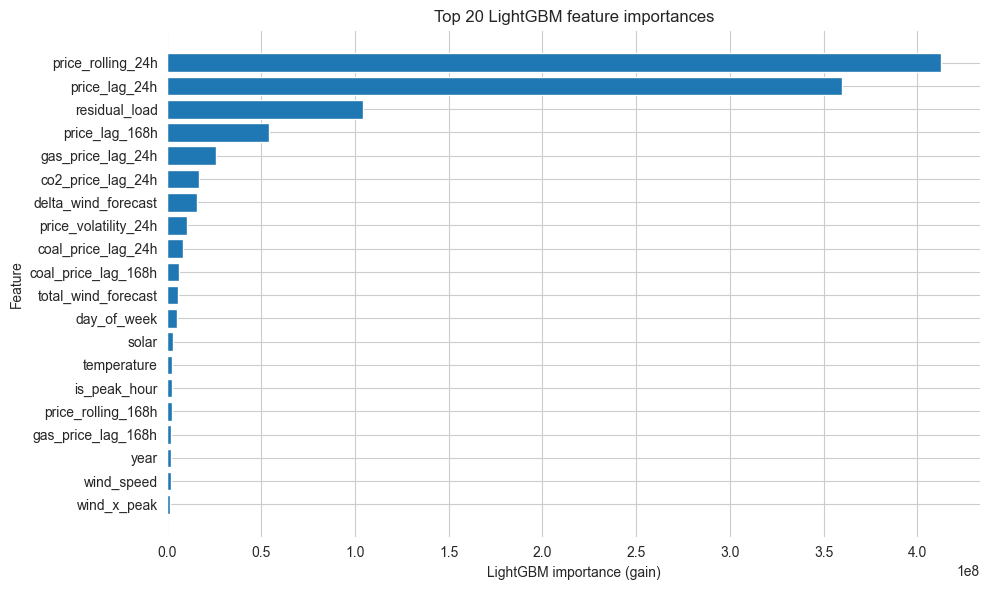

In [ ]:
# =========================================================
# 19. Plot LightGBM feature importance
# =========================================================

# Build a feature-importance table from the best LightGBM model
lgbm_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance_gain": best_lgbm_model.booster_.feature_importance(importance_type="gain"),
    "importance_split": best_lgbm_model.booster_.feature_importance(importance_type="split")
}).sort_values("importance_gain", ascending=False).reset_index(drop=True)

# Show the ranked importance table
display(lgbm_importance)

# Plot the top 20 features by gain
plt.figure(figsize=(10, 6))
plt.barh(
    lgbm_importance["feature"].head(20)[::-1],
    lgbm_importance["importance_gain"].head(20)[::-1]
)
plt.xlabel("LightGBM importance (gain)")
plt.ylabel("Feature")
plt.title("Top 20 LightGBM feature importances")
plt.tight_layout()
plt.show()